# 06 - Fairness & Bias Analysis

This fairness analysis evaluates whether the credit-risk prediction model behaves consistently across two key demographic attributes: age group and gender.

This notebook evaluates whether the credit-risk prediction model behaves fairly across different demographic groups. It supports Research Question 4 (RQ4) by computing fairness metrics such as disparate impact, equal opportunity difference, and false positive rate difference.

## Load the Libraries

In [ ]:
# Load the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    confusion_matrix
)

import urllib.request
import joblib

## Load the Cleaned Test Data

In [ ]:
# Load the Cleaned Test Data that was saved in GotHub during PReprocessing

test_url = "https://raw.githubusercontent.com/KrisAimlGitHub/credit-risk-capstone/main/data/processed/cleaned_credit_test.csv"
test_df = pd.read_csv(test_url)

print('Test Data Loaded.')
print('Shape of Test DF: ', test_df.shape)



Test Data Loaded.
Shape of Test DF:  (300, 62)


## Load the Raw Age Test Data

In [ ]:
# Load the Cleaned Test Data that was saved in GotHub during PReprocessing

test_url2 = "https://raw.githubusercontent.com/KrisAimlGitHub/credit-risk-capstone/main/data/processed/raw_age_test.csv"
test_age_df = pd.read_csv(test_url2)

print('Age Test Loaded.')
print('Shape of Age Test DF: ', test_age_df.shape)

Age Test Loaded.
Shape of Age Test DF:  (300, 1)


## Add Age to Test DF

In [ ]:
test_df['age_num'] = test_age_df['age']

## Load the Trained Model from GitHub

We use the same model interpreted in the SHAP notebook ( i.e Random Forest).


In [ ]:
# Load the Random Forest Model from GitHub (saved under Model Training)

model_filename = "random_forest.pkl"

base_url = "https://raw.githubusercontent.com/KrisAimlGitHub/credit-risk-capstone/main/models/"
url = base_url + model_filename

urllib.request.urlretrieve(url, model_filename)
model = joblib.load(model_filename)

print(f"Loaded model: {model_filename}")


Loaded model: random_forest.pkl


## Sensitive Attributes for Fairness Analysis

We evaluate fairness across:
- Gender (if available)
- Age groups (e.g., <30 vs ≥30)

These attributes are commonly used in credit‑risk fairness studies.

In [ ]:
# Take a copy of the Test DF
df = test_df.copy()

# Create 2 Age groups - 'Under 30'and '30 and above'
df['age_group'] = np.where(df['age_num'] < 30, 'Under 30', '30 and above')

# Create Gender groups 'personal_status' with A91, A93 and A94 are male
df['gender'] = np.where(
    (df.get('personal_status_A91', 0) == 1) |
    (df.get('personal_status_A93', 0) == 1) |
    (df.get('personal_status_A94', 0) == 1),
    'Male',
    'Female'
)

print('Age Group Distribution:')
print(df.age_group.value_counts())
print('\n')
print('Gender Distribution:')
print(df.gender.value_counts())

Age Group Distribution:
age_group
30 and above    176
Under 30        124
Name: count, dtype: int64


Gender Distribution:
gender
Male      199
Female    101
Name: count, dtype: int64


## Verify the Data

In [ ]:
df.head()

,checking_status_A11,checking_status_A12,checking_status_A13,checking_status_A14,credit_history_A30,credit_history_A31,credit_history_A32,credit_history_A33,credit_history_A34,purpose_A40,...,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,target,age_num,age_group,gender
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.141086,0.945404,-1.660121,1.053459,-0.724565,-0.434114,1,47,30 and above,Male
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.867507,0.945404,1.076342,-1.139072,1.074000,-0.434114,1,23,Under 30,Male
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.475912,0.945404,-0.747967,-0.408228,-0.724565,-0.434114,1,31,30 and above,Male
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.138372,0.945404,-0.747967,-0.225517,-0.724565,-0.434114,1,33,30 and above,Female
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.715245,0.945404,-1.660121,-1.321783,-0.724565,-0.434114,1,21,Under 30,Male


## Identify Features and Target

In [ ]:
X_test = df.drop(['target', 'age_group', 'age_num', 'gender'], axis=1)
y_test = df['target']

## Fairness Analysis on Age and Gender

### 1. Make Preictions on Test Data and take the Prediction Probablities

In [ ]:
# Predictions on Test Date

df['y_pred'] = model.predict(X_test)
df['y_prob'] = model.predict_proba(X_test)[:, 1]

### 2. Fairness Metric Functions

**2.1. Disparate Impact:** Disparate Impact measures whether different demographic groups receive favorable outcomes (e.g., predicted “good credit”) at similar rates. It is computed as the ratio of positive prediction rates between groups. A value below 0.80 indicates potential bias according to the “80% rule” (Feldman et al., 2015).

Reference:  
Feldman, M., et al. (2015). Certifying and removing disparate impact. KDD.

In [ ]:
def disparate_impact(df, group_col):
    """
    Favorable outcome rate ratio between groups.
    1.0 = perfectly fair
    <0.8 = potential disparate impact (80% rule)
    """
    positive_rate = df.groupby(group_col)['y_pred'].mean()
    return positive_rate.min() / positive_rate.max()

**2.2. Equal Opportunity Difference:** It compares the True Positive Rate (TPR) across demographic groups. It checks whether one group is more likely to be correctly identified as “bad credit” than another. A value close to 0 indicates fairness (Hardt et al., 2016).

Reference:  
Hardt, M., Price, E., & Srebro, N. (2016). Equality of Opportunity in Supervised Learning. NeurIPS.

In [ ]:
def equal_opportunity_difference(df, group_col):
    """
    Difference in True Positive Rates (Recall) across groups.
    0 = perfectly fair
    """
    recalls = df.groupby(group_col).apply(
        lambda g: recall_score(g['target'], g['y_pred'], pos_label=2)
    )
    return recalls.max() - recalls.min()

**2.3. False Positive Rate Difference (FPRD):** False Positive Rate Difference measures whether one group is incorrectly labeled as “bad credit” more often than another. It captures the disparity in false alarms across groups. A value near 0 indicates consistent error rates and fairer model behavior.

Reference:  
IBM AI Fairness 360 Toolkit (AIF360). Fairness metrics documentation.

In [ ]:
def false_positive_rate_difference(df, group_col):
    """
    Difference in FPR across groups.
    0 = perfectly fair
    """
    fprs = {}
    for group, g in df.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            g['target'], g['y_pred'], labels=[1, 2]
        ).ravel()
        fprs[group] = fp / (fp + tn)
    return max(fprs.values()) - min(fprs.values())

**24. Accuracy Difference:** Accuracy Difference evaluates whether the model performs equally well across demographic groups. It compares overall accuracy between groups to detect performance gaps. A value close to 0 indicates consistent predictive quality.

Reference:  
Barocas, S., Hardt, M., & Narayanan, A. (2019). Fairness and Machine Learning (Draft textbook).

In [ ]:
def accuracy_difference(df, group_col):
    """
    Difference in accuracy across groups.
    0 = perfectly fair
    """
    accuracies = df.groupby(group_col).apply(
        lambda g: accuracy_score(g['target'], g['y_pred'])
    )
    return accuracies.max() - accuracies.min()

### 3. Compute Fairness Metrics for Age Group & Gender

In [ ]:
# 3. Compute Fairness Metrics for Age Group & Gender

metrics = {
    "Metric": [
        "Disparate Impact",
        "Equal Opportunity Difference",
        "FPR Difference",
        "Accuracy Difference"
    ],

    "Age Group": [
        disparate_impact(df, 'age_group'),
        equal_opportunity_difference(df, 'age_group'),
        false_positive_rate_difference(df, 'age_group'),
        accuracy_difference(df, 'age_group')
    ],

    "Gender": [
        disparate_impact(df, 'gender'),
        equal_opportunity_difference(df, 'gender'),
        false_positive_rate_difference(df, 'gender'),
        accuracy_difference(df, 'gender')
    ]
}

fairness_df = pd.DataFrame(metrics)
fairness_df


/tmp/ipykernel_4862/1639887821.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recalls = df.groupby(group_col).apply(
/tmp/ipykernel_4862/2421758605.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracies = df.groupby(group_col).apply(
/tmp/ipykernel_4862/1639887821.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future vers

,Metric,Age Group,Gender
0,Disparate Impact,0.937839,0.968936
1,Equal Opportunity Difference,0.032162,0.064935
2,FPR Difference,0.036227,0.007576
3,Accuracy Difference,0.085777,0.011344


### 4. Fairness Metrics Visualization

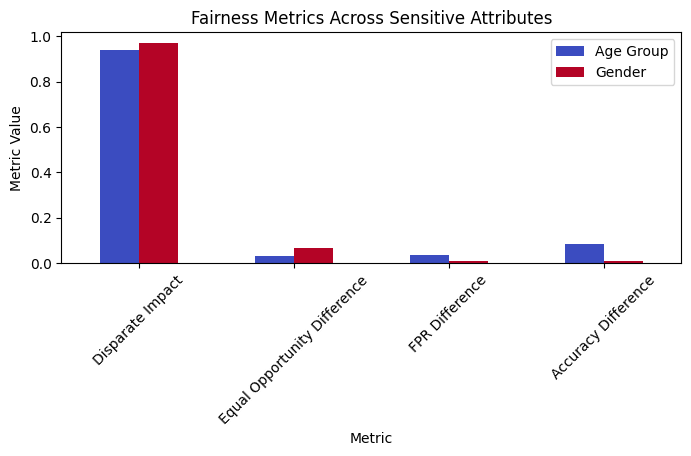

In [ ]:
fairness_df.set_index("Metric").plot(
    kind="bar",
    figsize=(8, 3),
    colormap="coolwarm"
)

plt.title("Fairness Metrics Across Sensitive Attributes")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.show()

## Summary on Fairness Analysis

- Fairness was evaluated across two sensitive attributes: age group and gender.

- Raw age values were restored, and gender was reconstructed from encoded personal‑status features.

- Four fairness metrics were computed: Disparate Impact, Equal Opportunity Difference, False Positive Rate Difference, and Accuracy Difference.

- All metrics showed small differences across groups, indicating no major fairness concerns.

- The fairness plot confirmed consistent and equitable model behavior across demographic segments.

Note: Detailed discussion on the observations will be presented in the report.